# EDA for Malaysia Residential Property Data (Pahang) with multi-python library


In [8]:
import pandas as pd # for data manipulation and analysis
import numpy as np
import missingno as msno # uncovering missing data patterns in datasets
import matplotlib.pyplot as plt # for plotting graph
import seaborn as sns
import sweetviz as sv

In [4]:
df = pd.read_csv('Malaysia Residential Property Data.csv', sep='\t', encoding='utf-8')

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)



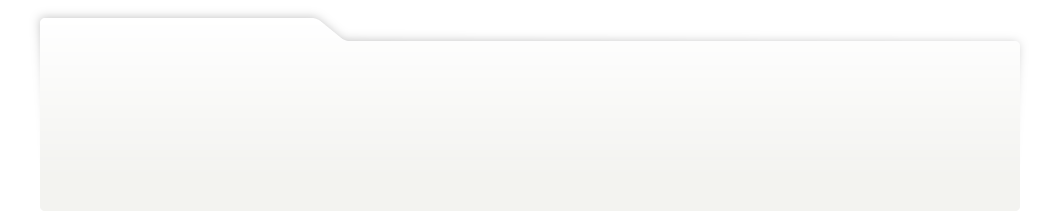
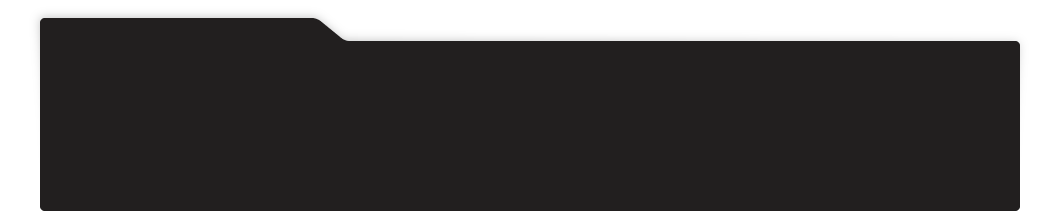
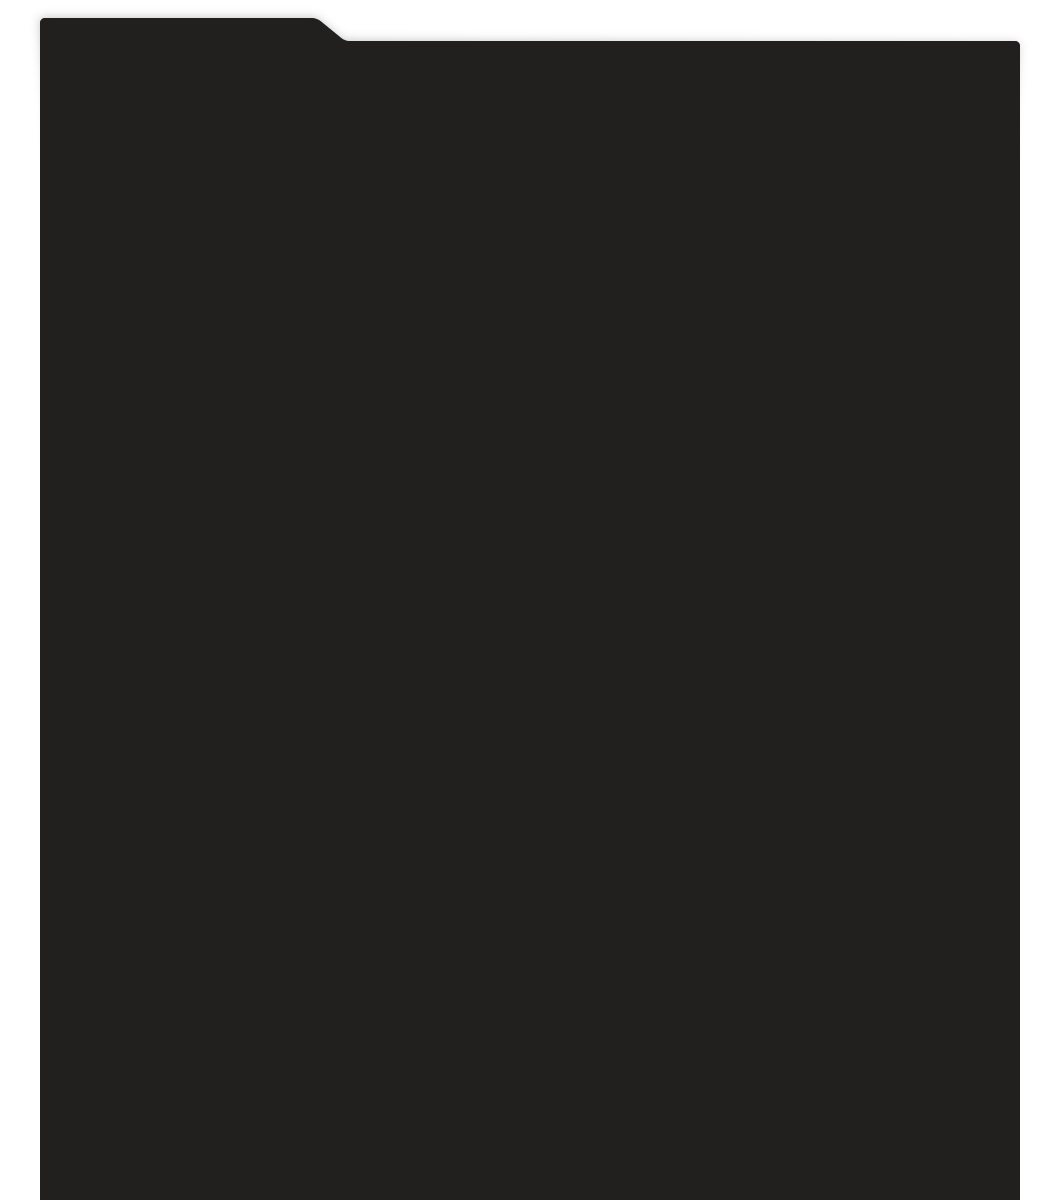
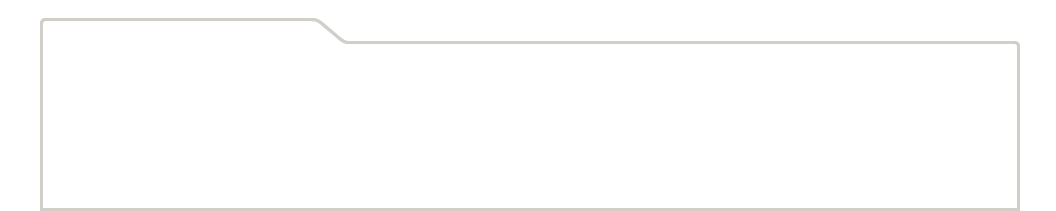
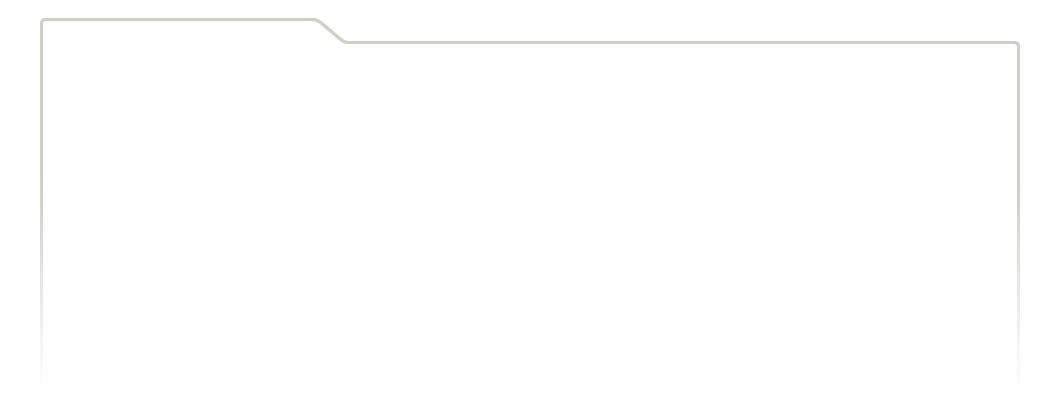
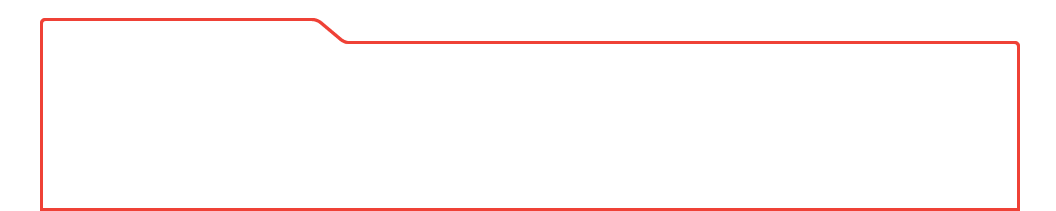
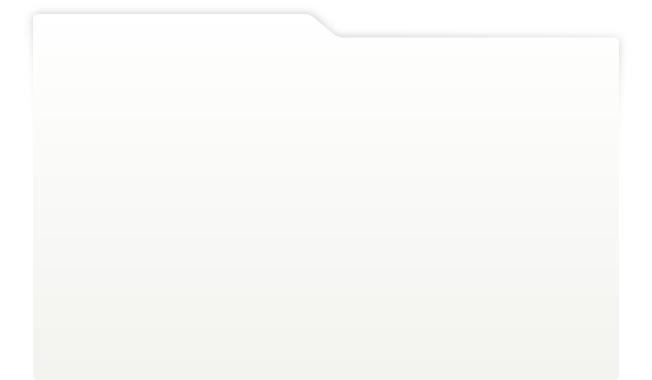
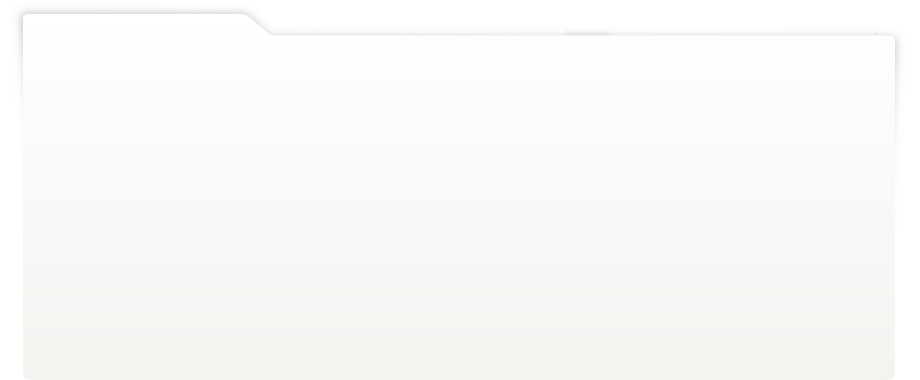
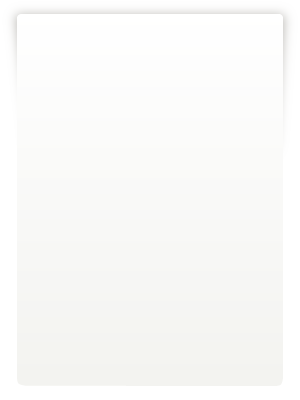
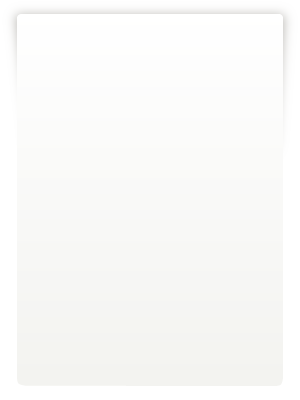
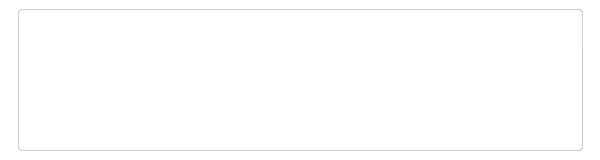
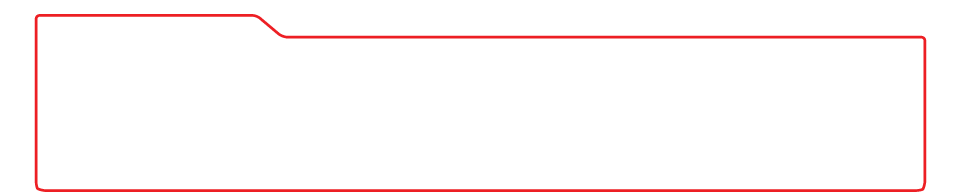
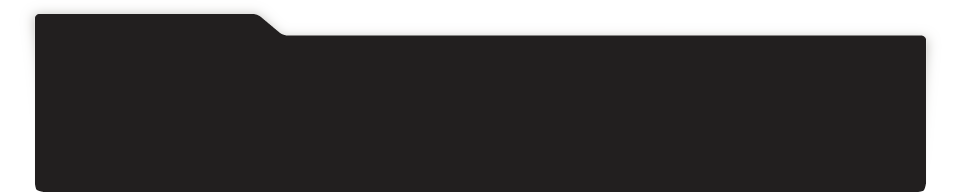
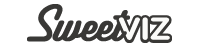
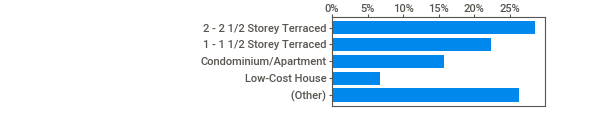
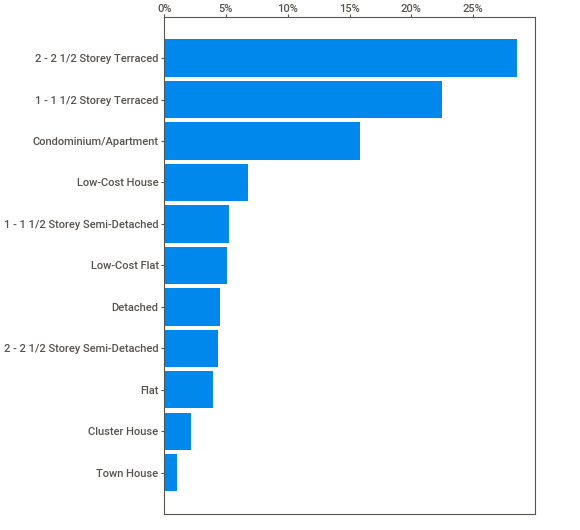
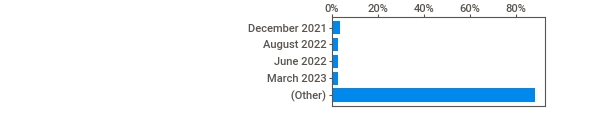
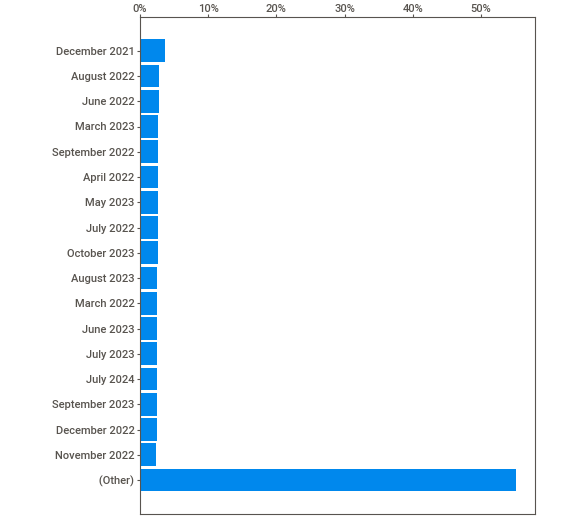
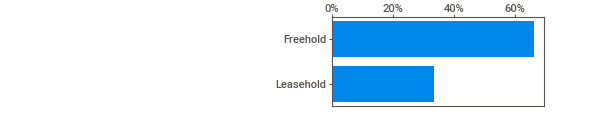
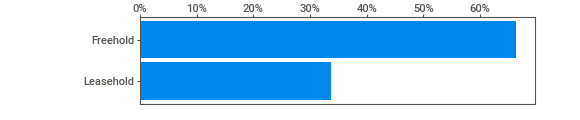
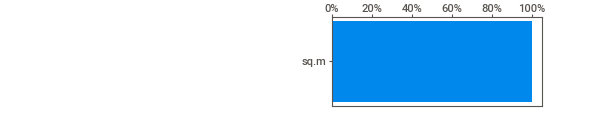
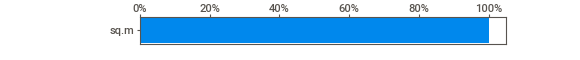
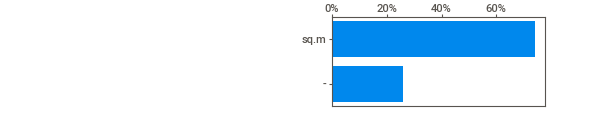
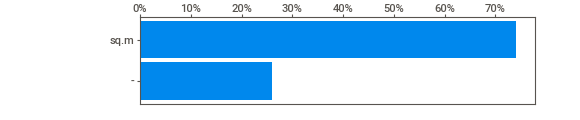
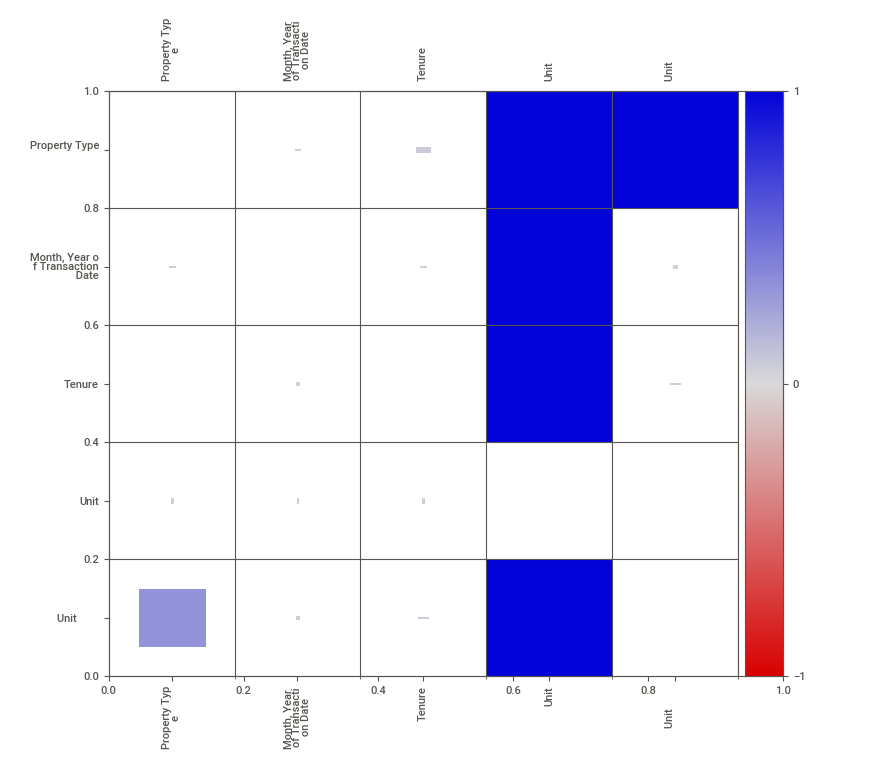
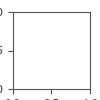

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [ ]:
report = sv.analyze(df)
report.show_notebook() # or .show_html()

In [6]:
df.head()

,Property Type,District,Mukim,Scheme Name/Area,Road Name,"Month, Year of Transaction Date",Tenure,Land/Parcel Area,Unit,Main Floor Area,Unit,Unit Level,Transaction Price,Unnamed: 13
0,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Bdr Masjid Tanah,TMN BUKIT INDAH FASA 2,JLN BUKIT INDAH 6,March 2024,Freehold,374.00,sq.m,106,sq.m,,"RM470,000.00",NaN
1,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN BELIMBING HARMONI,JLN BELIMBING HARMONI,May 2023,Leasehold,234.00,sq.m,67,sq.m,,"RM483,000.00",NaN
2,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,April 2021,Freehold,268.00,sq.m,118,sq.m,,"RM359,000.00",NaN
3,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,April 2021,Freehold,268.00,sq.m,118,sq.m,,"RM435,000.00",NaN
4,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,April 2021,Freehold,297.00,sq.m,118,sq.m,,"RM373,000.00",NaN


In [7]:

df.dtypes

Property Type                          str
District                               str
Mukim                                  str
Scheme Name/Area                       str
Road Name                              str
Month, Year of Transaction Date        str
Tenure                                 str
Land/Parcel Area                       str
Unit                                   str
Main Floor Area                        str
Unit                                   str
Unit Level                             str
Transaction Price                      str
Unnamed: 13                        float64
dtype: object

In [8]:
df.shape

(410959, 14)

<Axes: >

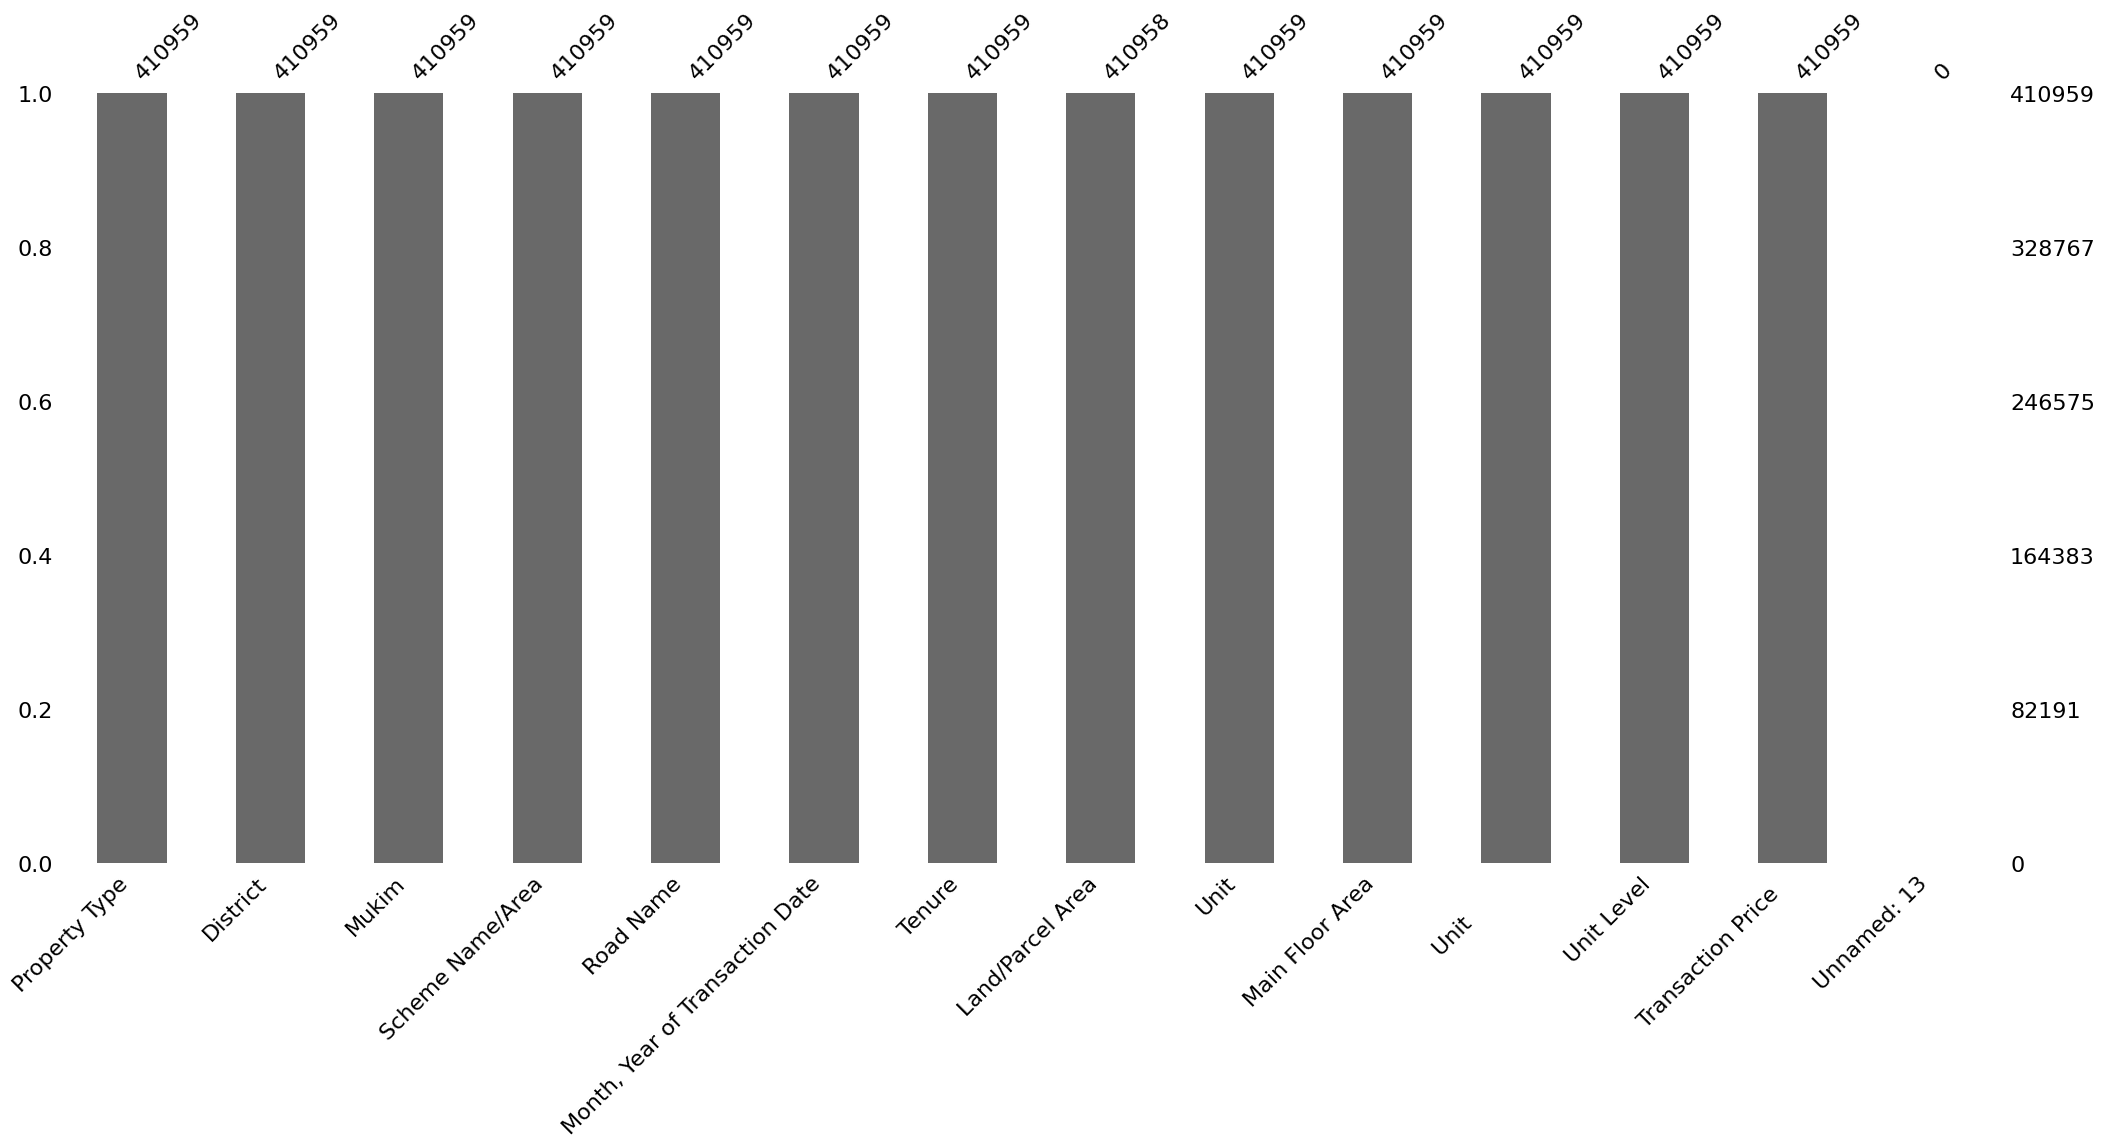

In [9]:
msno.bar(df) 

In [10]:
print("\nExisting column :\n " + f"{df.columns.tolist()}") # inspect column name, view any whitespace


Existing column :
 ['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Unit', 'Main Floor Area', 'Unit        ', 'Unit Level', 'Transaction Price  ', 'Unnamed: 13']


In [11]:

df.duplicated().sum() # total count of duplicate rows present in the DataFrame:

np.int64(447)

In [12]:
for i in df.columns: # checking total null values/NaN in a column
    print(i," : ",df[i].isnull().sum()) # OR print(i," : ",df[i].isna().sum())

Property Type  :  0
District  :  0
Mukim  :  0
Scheme Name/Area  :  0
Road Name  :  0
Month, Year of Transaction Date  :  0
Tenure  :  0
Land/Parcel Area  :  1
Unit  :  0
Main Floor Area  :  0
Unit          :  0
Unit Level  :  0
Transaction Price    :  0
Unnamed: 13  :  410959


**Data wrangling**

In [13]:

df.columns = df.columns.str.strip() # remove leading/trailing spaces in column names and print the output after column stripped
print("\nColumn after stripped :\n" + f"{df.columns.tolist()}\n")


Column after stripped :
['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Unit', 'Main Floor Area', 'Unit', 'Unit Level', 'Transaction Price', 'Unnamed: 13']



In [14]:
df = df.dropna(axis=1, how='all') # remove the entire column only if all values are NaN and print the output after removed NaN column:
print("\nResult after remove NaN column :\n"+ f"{df.columns.tolist()}")


Result after remove NaN column :
['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Unit', 'Main Floor Area', 'Unit', 'Unit Level', 'Transaction Price']


In [15]:
# Clean and convert 'Transaction Price' to numeric
df['Transaction Price'] = df['Transaction Price'].str.replace('RM', '', regex=False)
df['Transaction Price'] = df['Transaction Price'].str.replace(',', '', regex=False).astype(float)

print(df['Land/Parcel Area'].unique())
print(df['Land/Parcel Area'][df['Land/Parcel Area'] == ''])  # find empty strings

# Clean and convert 'Land/Parcel Area' to numeric
df['Land/Parcel Area'] = df['Land/Parcel Area'].str.replace(',', '', regex=False).astype(float)

print(df['Main Floor Area'].unique())
print(df['Main Floor Area'][df['Main Floor Area'] == ''])  # find empty strings

# Clean and convert 'Main Floor Area' to numeric
df['Main Floor Area'] = df['Main Floor Area'].str.replace('-', '', regex=False)
df['Main Floor Area'] = df['Main Floor Area'].str.replace(',', '', regex=False).replace('', np.nan).astype(float)

<StringArray>
['374.00', '234.00', '268.00', '297.00', '331.00', '387.00', '478.00',
 '490.00', '433.00', '290.00',
 ...
 '150.31',  '97.63',  '96.52',  '96.53',  '99.86',  '81.70',  '90.81',
 '132.28',  '70.29', '359.63']
Length: 17613, dtype: str
Series([], Name: Land/Parcel Area, dtype: str)
<StringArray>
[  '106',    '67',   '118',   '116',   '217',   '143',    '82',   '133',
   '117',    '93',
 ...
   '630', '1,360',   '661', '2,178', '1,755',   '707',   '610',   '561',
 '1,823',    '23']
Length: 825, dtype: str
Series([], Name: Main Floor Area, dtype: str)


In [16]:
# Convert 'Month, Year of Transaction Date' to datetime
df['Transaction Date'] = pd.to_datetime(df['Month, Year of Transaction Date'], format='%B %Y')

**Analayze data after data wrangling**

In [17]:

df.dtypes

Property Type                                 str
District                                      str
Mukim                                         str
Scheme Name/Area                              str
Road Name                                     str
Month, Year of Transaction Date               str
Tenure                                        str
Land/Parcel Area                          float64
Unit                                          str
Main Floor Area                           float64
Unit                                          str
Unit Level                                    str
Transaction Price                         float64
Transaction Date                   datetime64[us]
dtype: object

<Axes: >

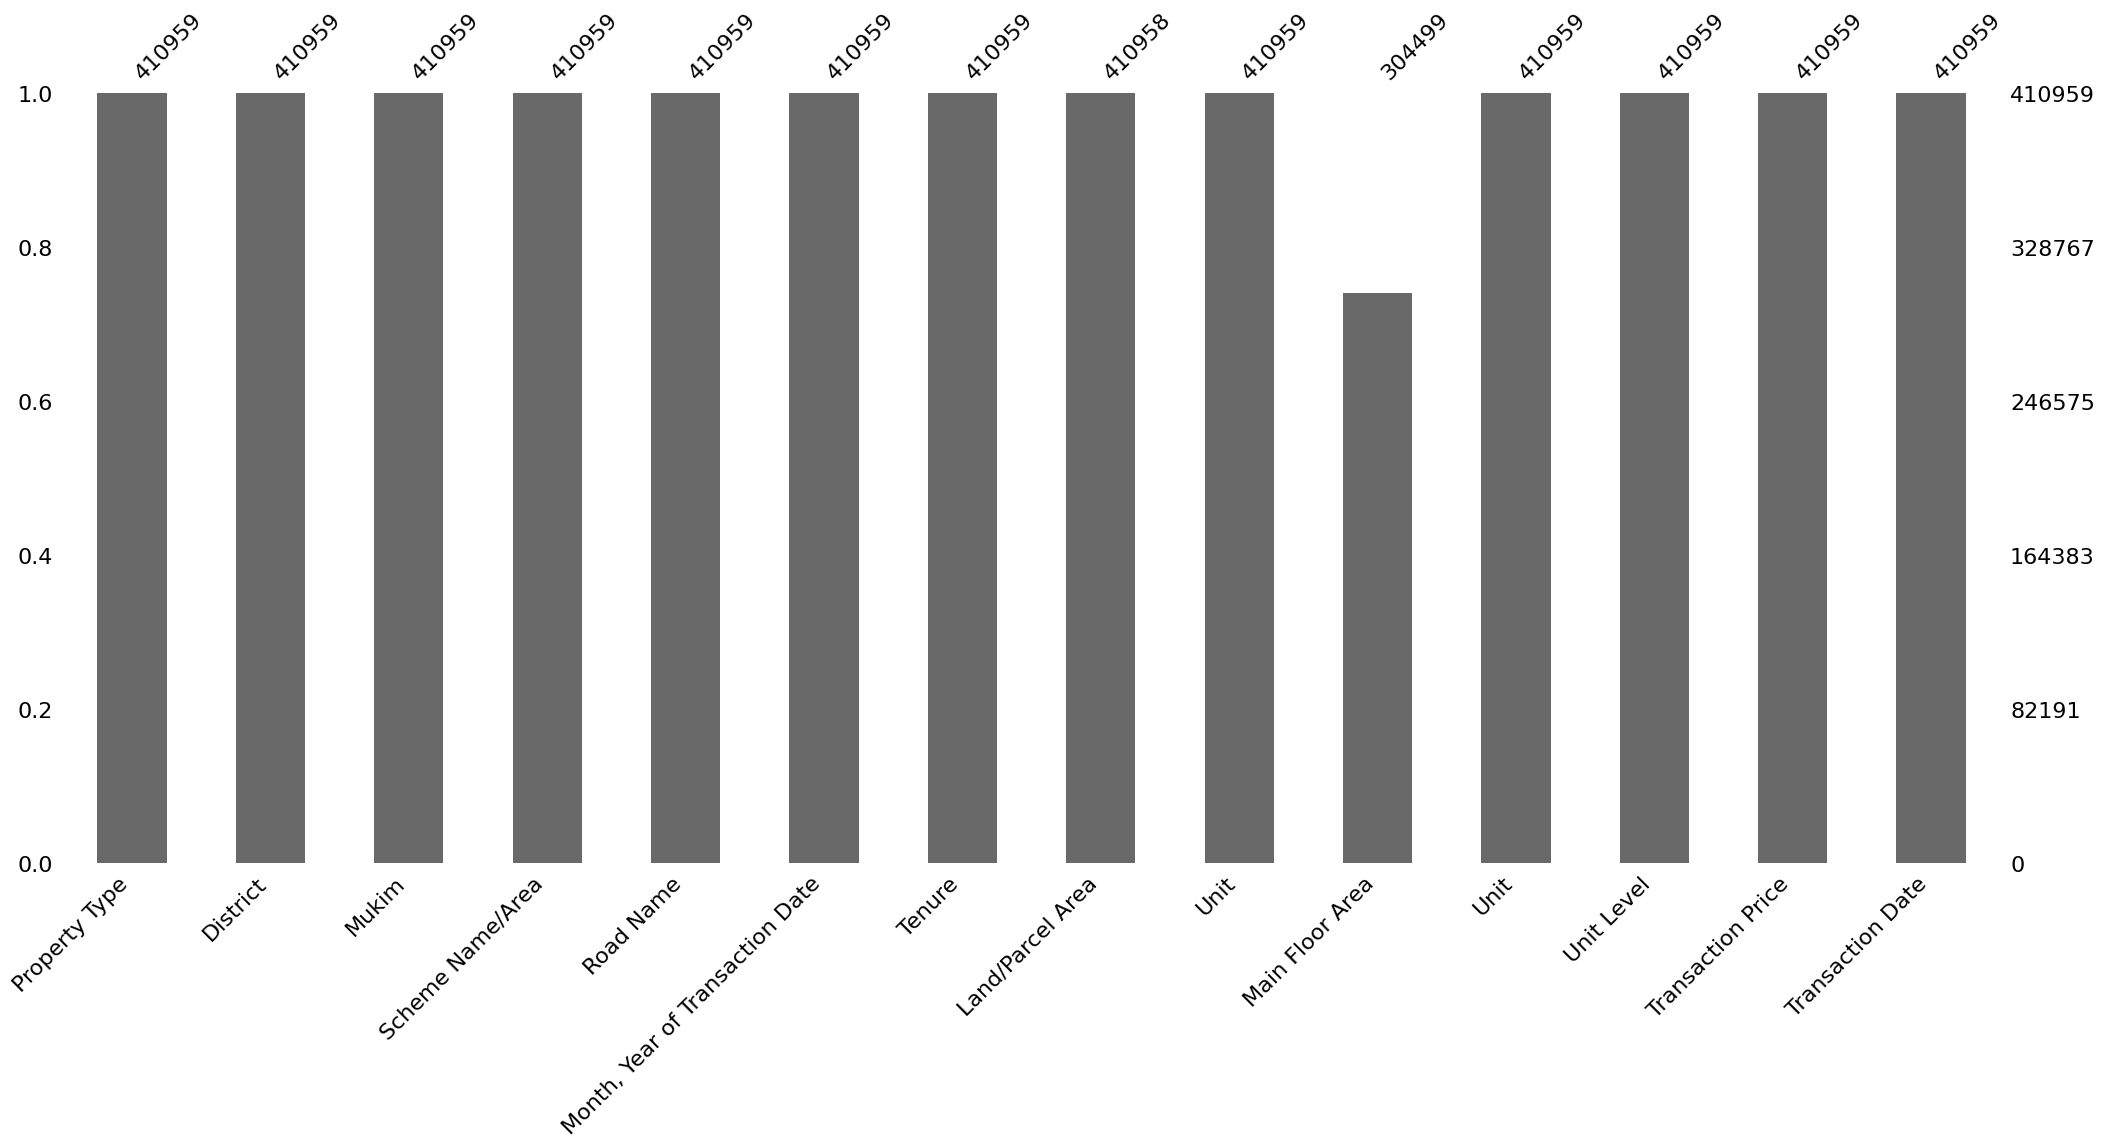

In [18]:
msno.bar(df) # visualizing missing numeric data with bar chart (missingno library)

<Axes: >

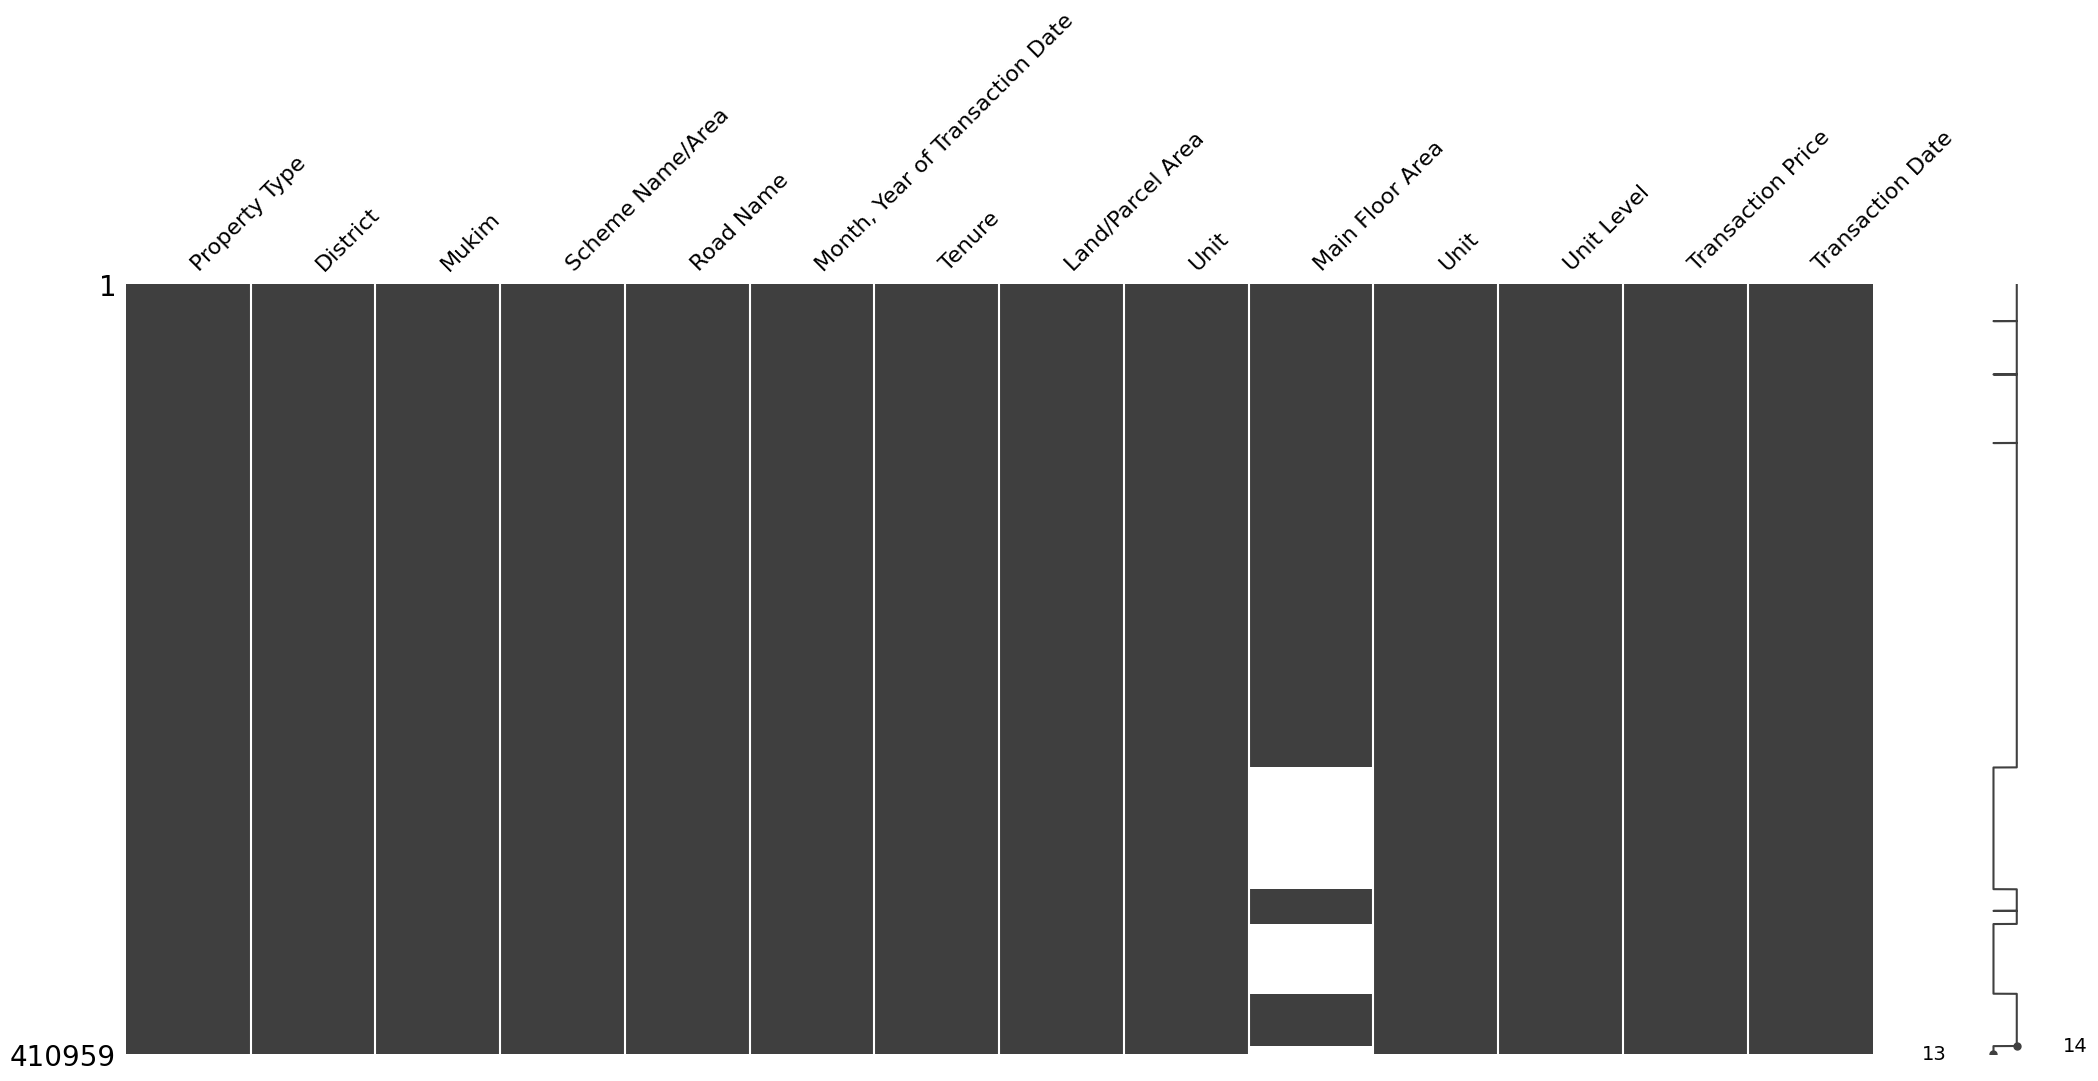

In [19]:
msno.matrix(df)  # visualizing missing numeric data with Matrix plot (missingno library)

**Handle missing values**

In [20]:
# Handle missing values in 'Main Floor Area' by filling with the median
df['Main Floor Area'] = df['Main Floor Area'].fillna(df['Main Floor Area'].median())

<Axes: >

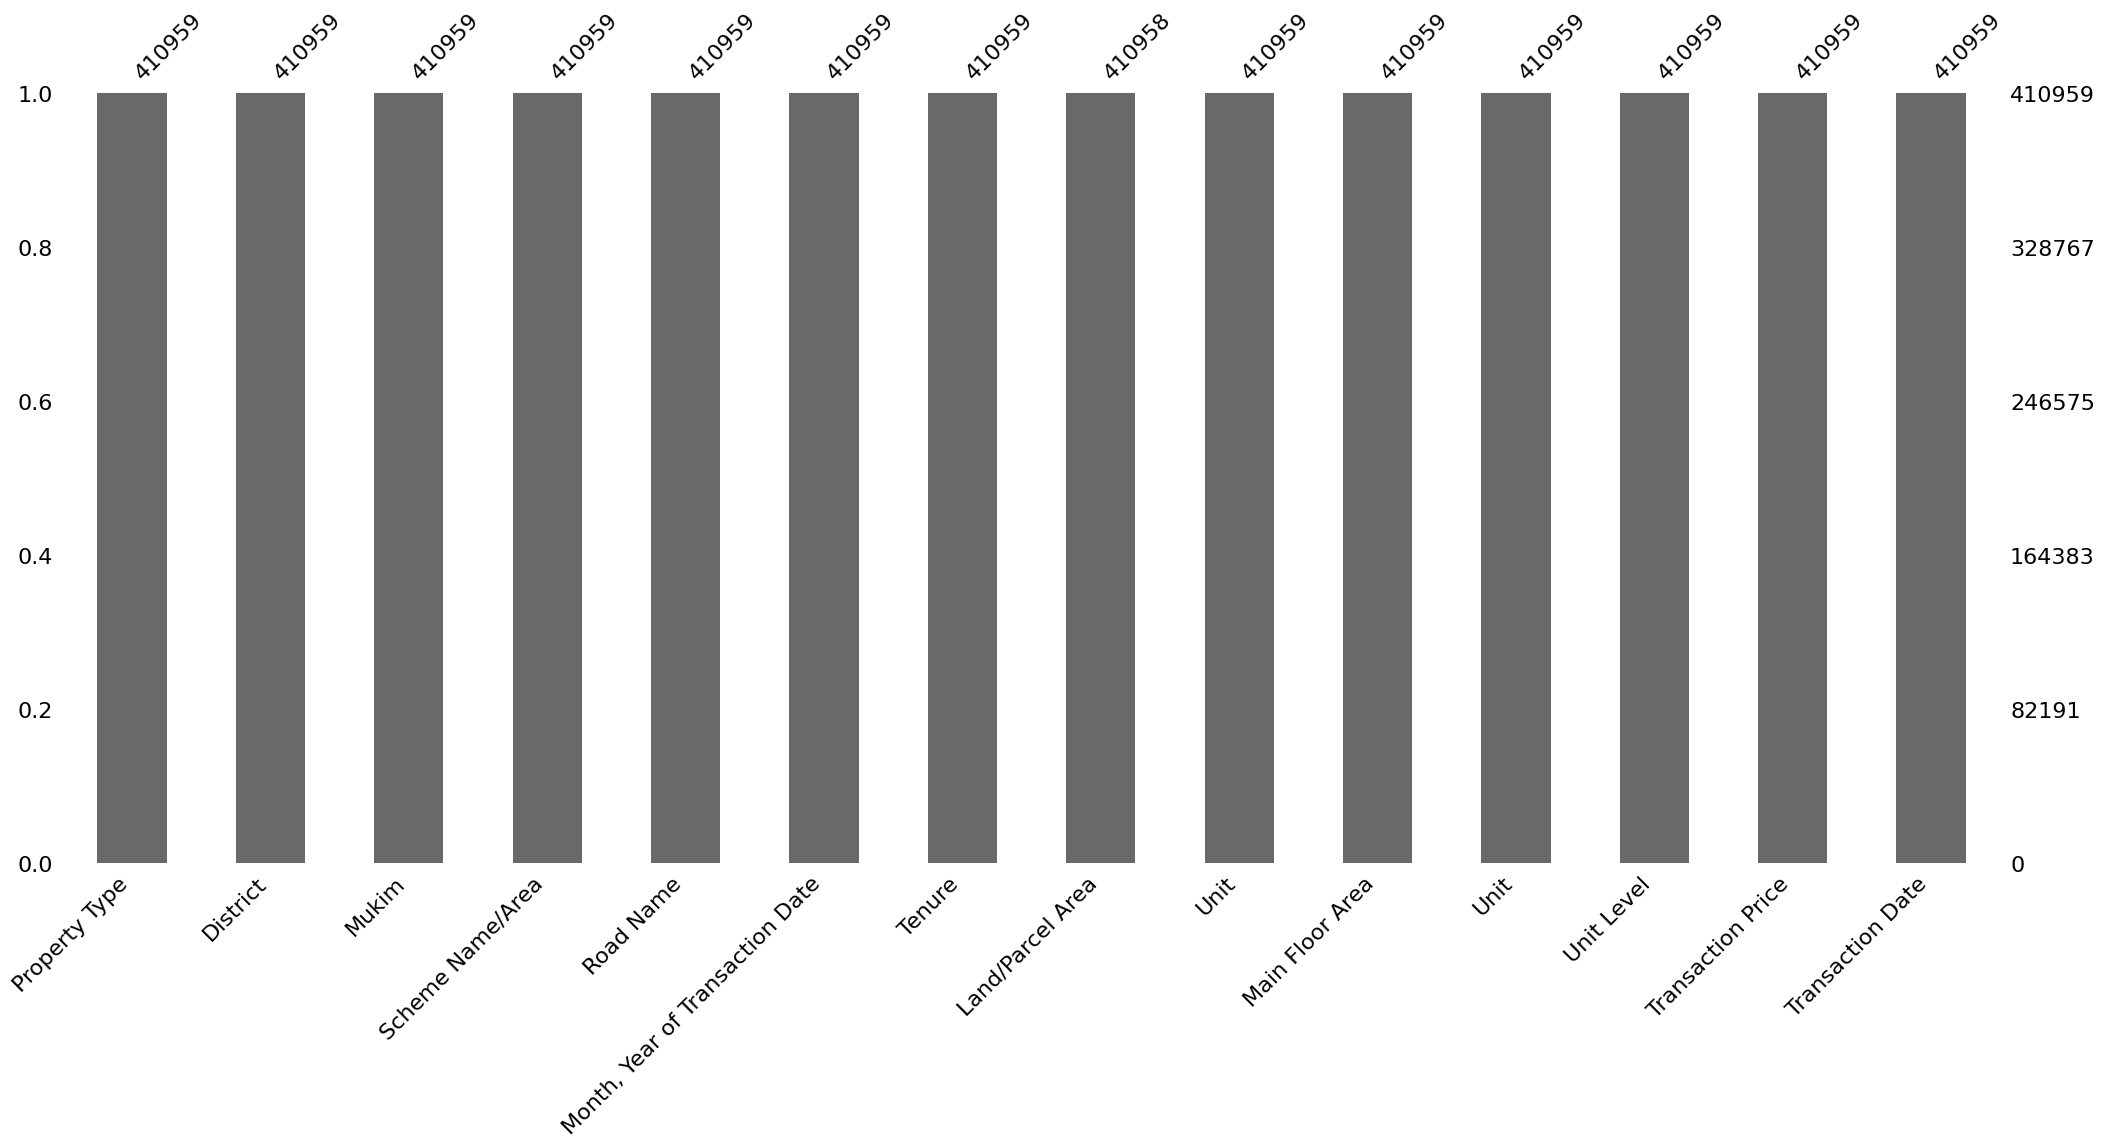

In [21]:
msno.bar(df)

<Axes: >

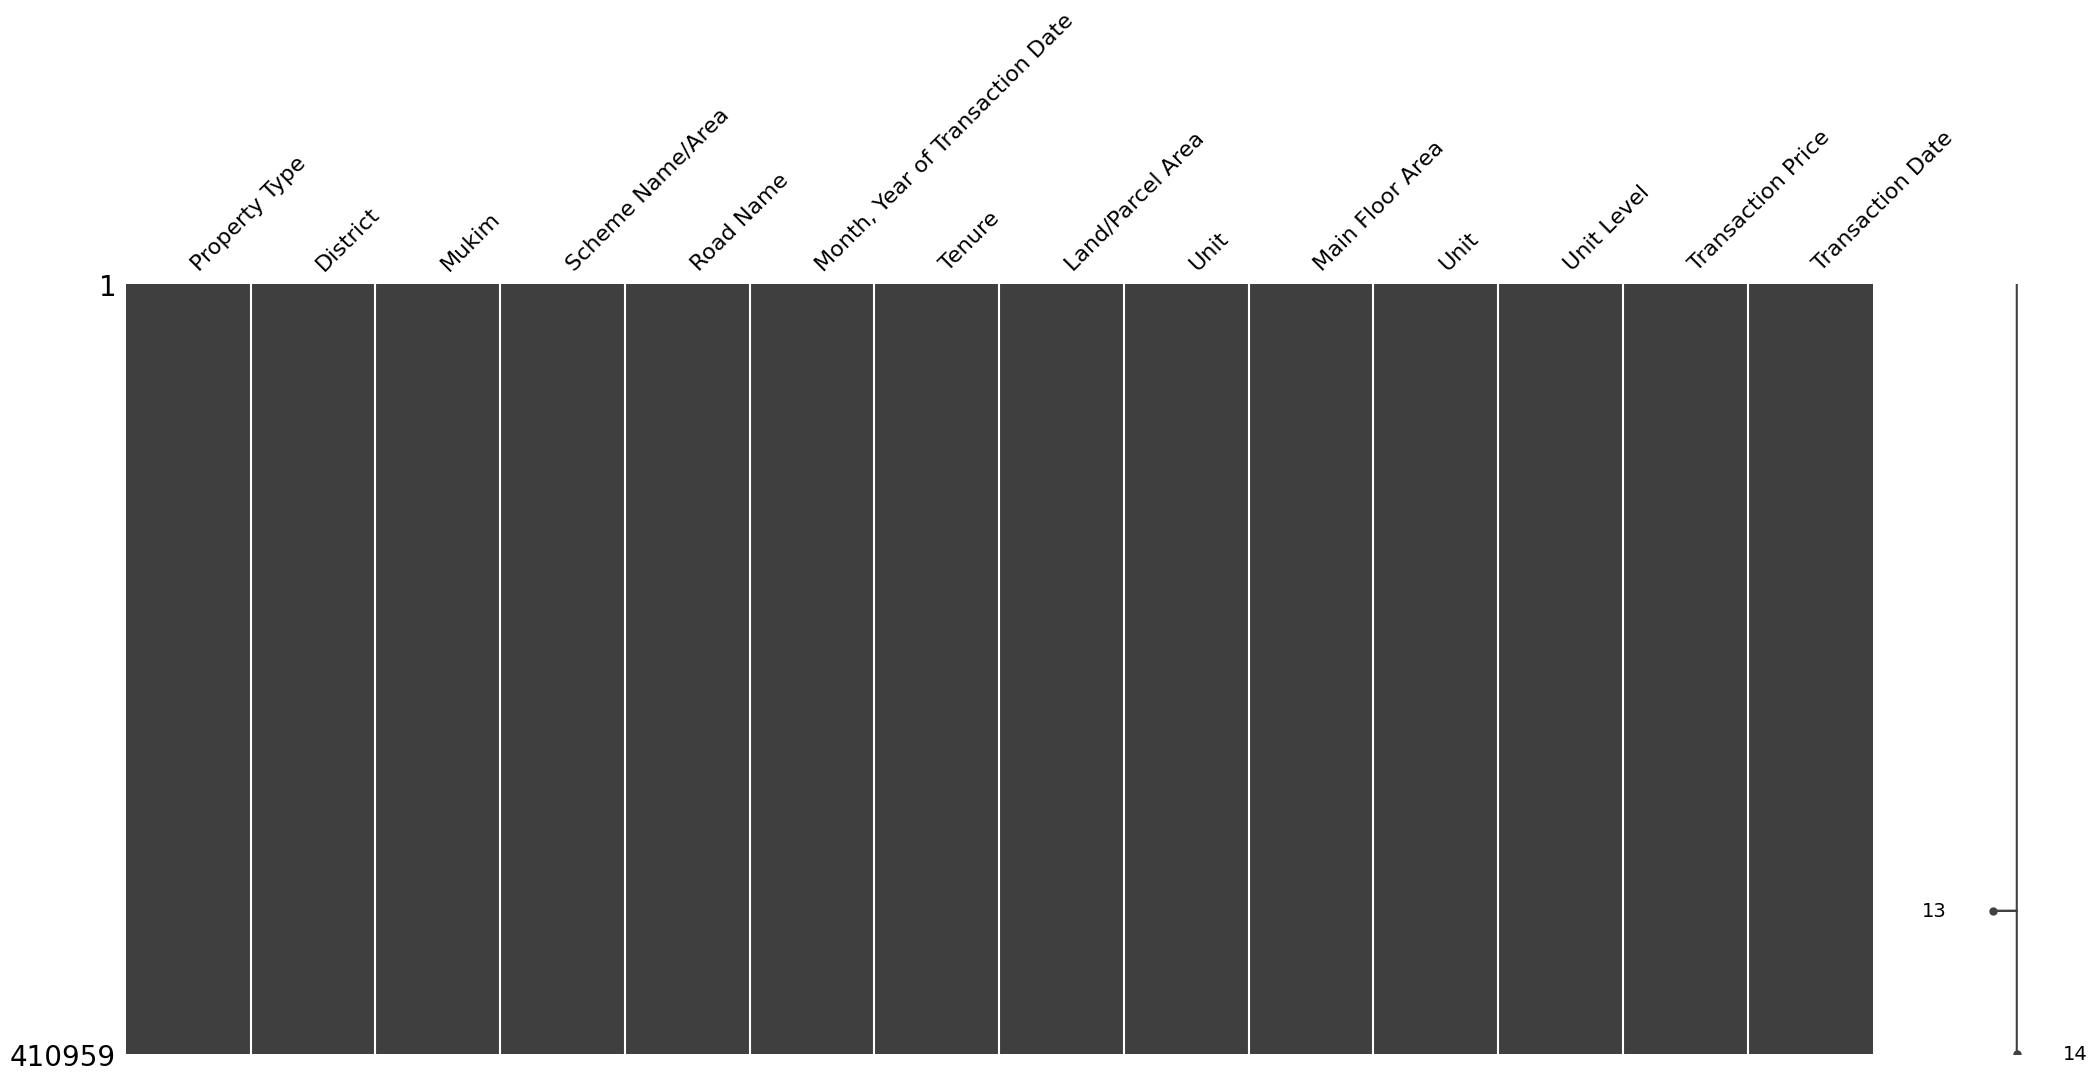

In [22]:
msno.matrix(df) 

**Pahang Residential Property Analysis**

In [23]:
# List of districts in Pahang
pahang_districts = [
    'Bera', 'Cameron Highlands', 'Jerantut', 'Kuantan',
    'Lipis', 'Maran', 'Pekan', 'Raub', 'Rompin',
    'Temerloh', 'Bentong'
]

# Filter the dataframe for Pahang districts
df_pahang = df[df['District'].isin(pahang_districts)]

# Aggregate by District: count the number of properties per district
district_counts = df_pahang.groupby('District').size().sort_values(ascending=False)
print(district_counts)

District
Kuantan     10558
Temerloh     1800
Bentong      1111
Rompin        978
Raub          831
Jerantut      700
Bera          628
Pekan         605
Lipis         551
Maran         405
dtype: int64


         Transaction Price                                           \
                     count       mean    median      min        max   
District                                                              
Bentong               1111  384905.49  320000.0  21000.0  9000000.0   
Bera                   628  276087.58  250000.0  23000.0   739000.0   
Jerantut               700  262501.43  263000.0  50000.0   850000.0   
Kuantan              10558  326989.87  289000.0  15000.0  3800000.0   
Lipis                  551  229869.33  250000.0  23000.0   787000.0   
Maran                  405  250108.64  244000.0  21000.0   669000.0   
Pekan                  605  265907.44  259000.0  12000.0   830000.0   
Raub                   831  354208.18  330000.0  12000.0  1300000.0   
Rompin                 978  184663.60  150000.0  12000.0   740000.0   
Temerloh              1800  290105.00  260000.0  25000.0  1100000.0   

         Main Floor Area        Land/Parcel Area         
                  

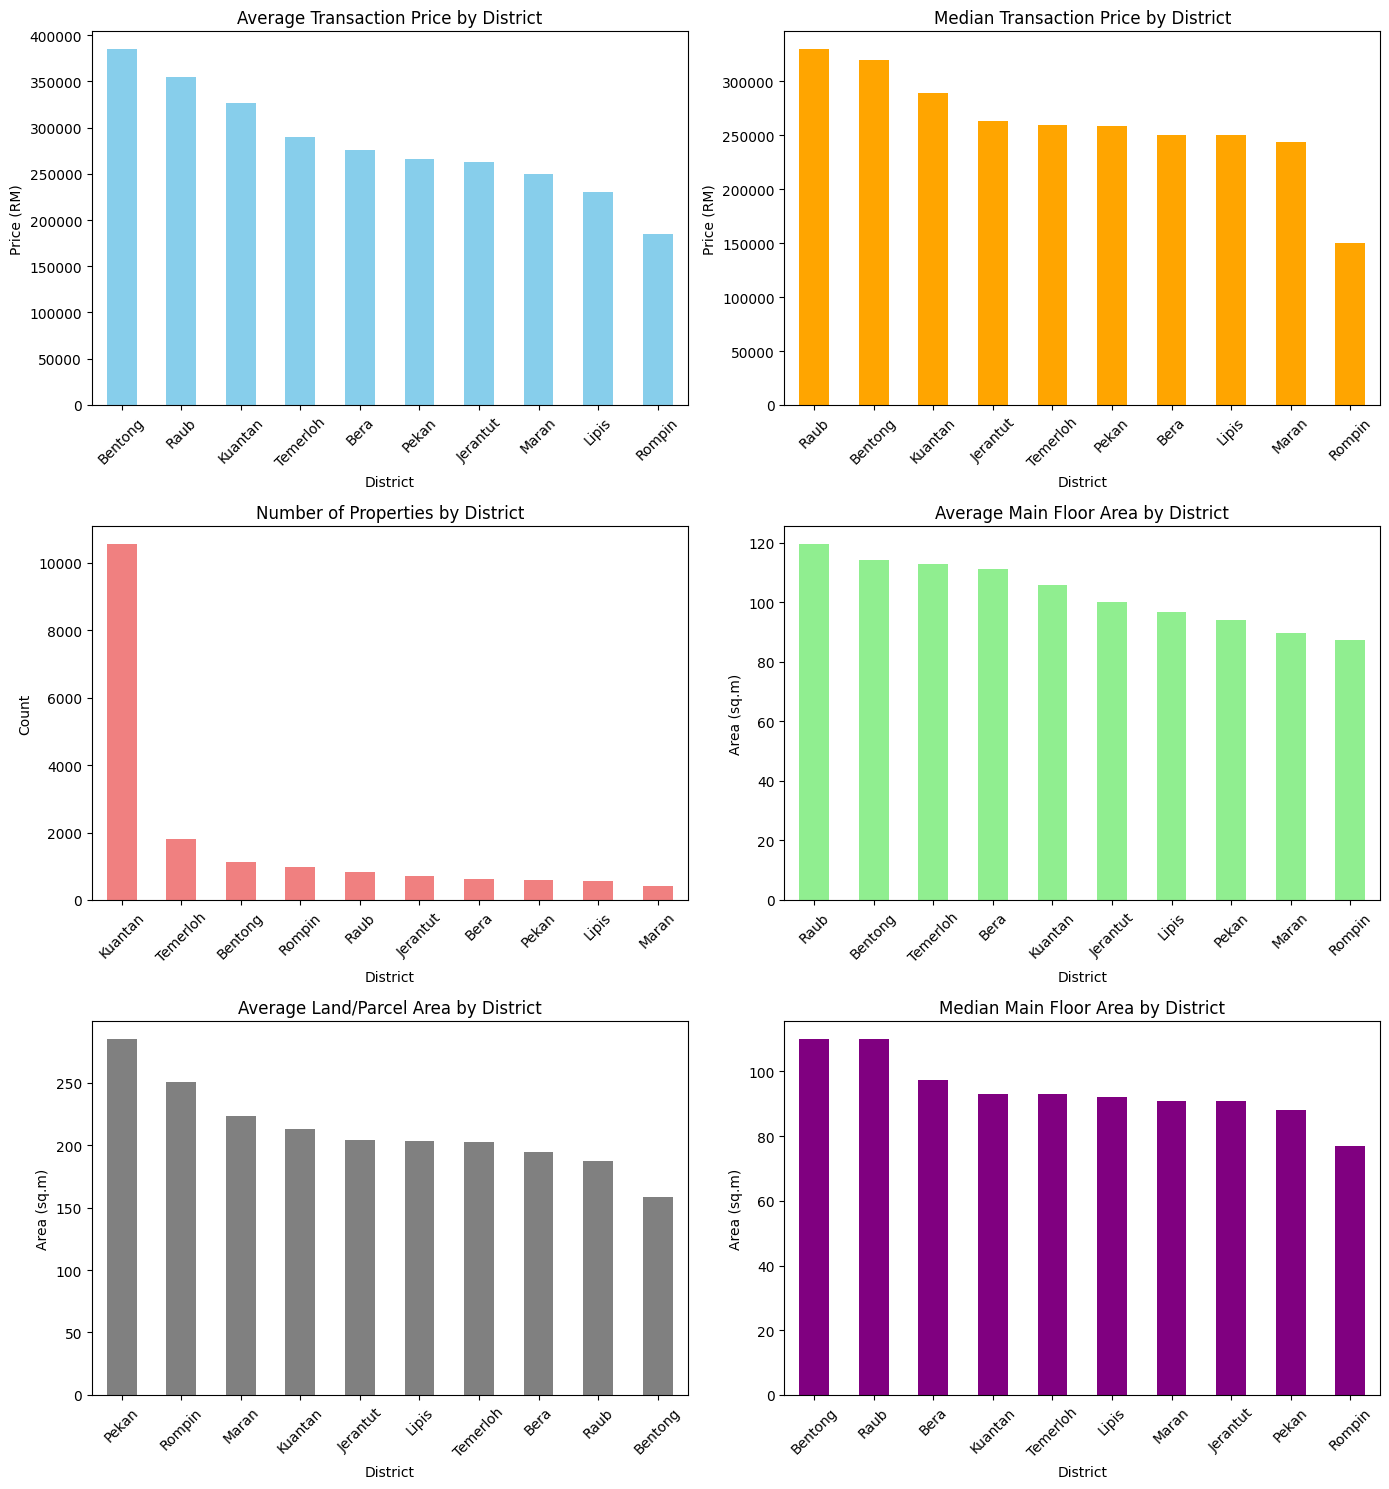

In [24]:
# Create a comparison table of all districts
district_comparison = df_pahang.groupby('District').agg({
    'Transaction Price': ['count', 'mean', 'median', 'min', 'max'],
    'Main Floor Area': ['mean', 'median'],
    'Land/Parcel Area': ['mean', 'median']
}).round(2)

print(district_comparison)

# Visualize the comparison
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# Average Transaction Price by District
df_pahang.groupby('District')['Transaction Price'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Average Transaction Price by District')
axes[0, 0].set_ylabel('Price (RM)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Median Transaction Price by District
df_pahang.groupby('District')['Transaction Price'].median().sort_values(ascending=False).plot(kind='bar', ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Median Transaction Price by District')
axes[0, 1].set_ylabel('Price (RM)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Number of Properties by District
district_counts.sort_values(ascending=False).plot(kind='bar', ax=axes[1, 0], color='lightcoral')
axes[1, 0].set_title('Number of Properties by District')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Average Main Floor Area by District
df_pahang.groupby('District')['Main Floor Area'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[1, 1], color='lightgreen')
axes[1, 1].set_title('Average Main Floor Area by District')
axes[1, 1].set_ylabel('Area (sq.m)')
axes[1, 1].tick_params(axis='x', rotation=45)

# Average Land/Parcel Area by District
df_pahang.groupby('District')['Land/Parcel Area'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[2, 0], color='grey')
axes[2, 0].set_title('Average Land/Parcel Area by District')
axes[2, 0].set_ylabel('Area (sq.m)')
axes[2, 0].tick_params(axis='x', rotation=45)

# Median Main Floor Area by District (for completeness)
df_pahang.groupby('District')['Main Floor Area'].median().sort_values(ascending=False).plot(kind='bar', ax=axes[2, 1], color='purple')
axes[2, 1].set_title('Median Main Floor Area by District')
axes[2, 1].set_ylabel('Area (sq.m)')
axes[2, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Bivarate & Multivariate Analysis**

Correlation Matrix for Pahang:
                   Transaction Price  Main Floor Area  Land/Parcel Area
Transaction Price           1.000000         0.694745          0.055154
Main Floor Area             0.694745         1.000000          0.041774
Land/Parcel Area            0.055154         0.041774          1.000000


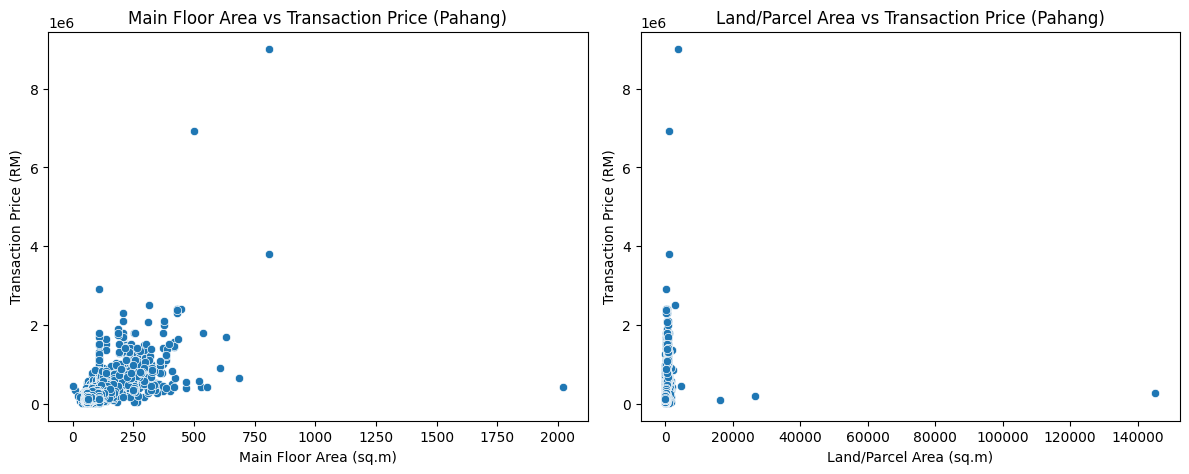

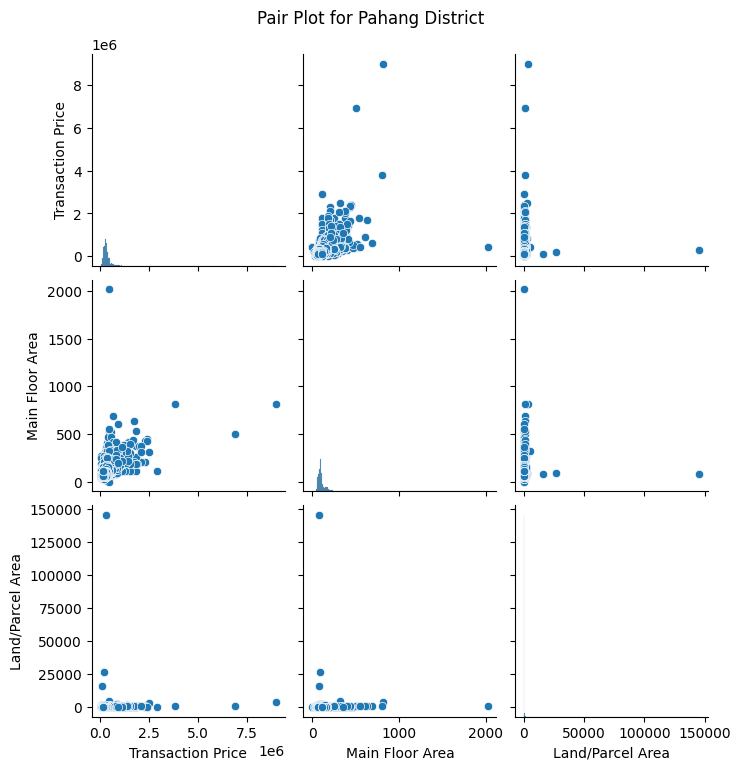

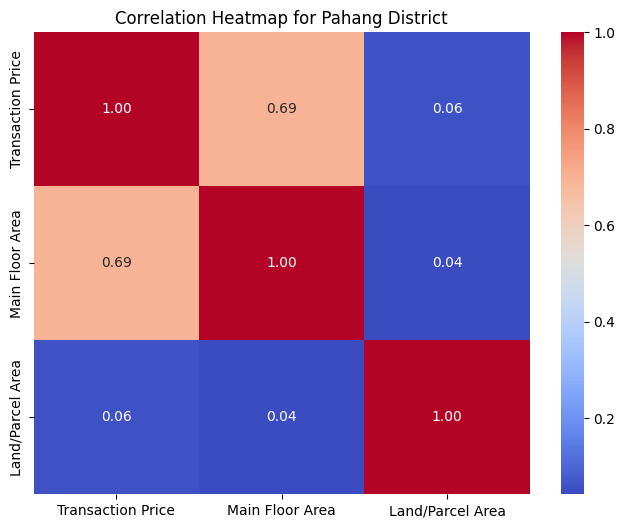

In [25]:
# Bivariate and Multivariate Analysis for Pahang District

# Select numeric columns for analysis
numeric_cols = ['Transaction Price', 'Main Floor Area', 'Land/Parcel Area']

# Compute correlation matrix
correlation_matrix_pahang = df_pahang[numeric_cols].corr()
print("Correlation Matrix for Pahang:")
print(correlation_matrix_pahang)

# Bivariate Analysis: Scatter plots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot: Main Floor Area vs Transaction Price
sns.scatterplot(data=df_pahang, x='Main Floor Area', y='Transaction Price', ax=ax[0])
ax[0].set_title('Main Floor Area vs Transaction Price (Pahang)')
ax[0].set_xlabel('Main Floor Area (sq.m)')
ax[0].set_ylabel('Transaction Price (RM)')

# Scatter plot: Land/Parcel Area vs Transaction Price
sns.scatterplot(data=df_pahang, x='Land/Parcel Area', y='Transaction Price', ax=ax[1])
ax[1].set_title('Land/Parcel Area vs Transaction Price (Pahang)')
ax[1].set_xlabel('Land/Parcel Area (sq.m)')
ax[1].set_ylabel('Transaction Price (RM)')

plt.tight_layout()
plt.show()

# Multivariate Analysis: Pair plot
sns.pairplot(df_pahang[numeric_cols])
plt.suptitle('Pair Plot for Pahang District', y=1.02)
plt.show()

# Heatmap of correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_pahang, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap for Pahang District')
plt.show()

**Kuantan district analysis**

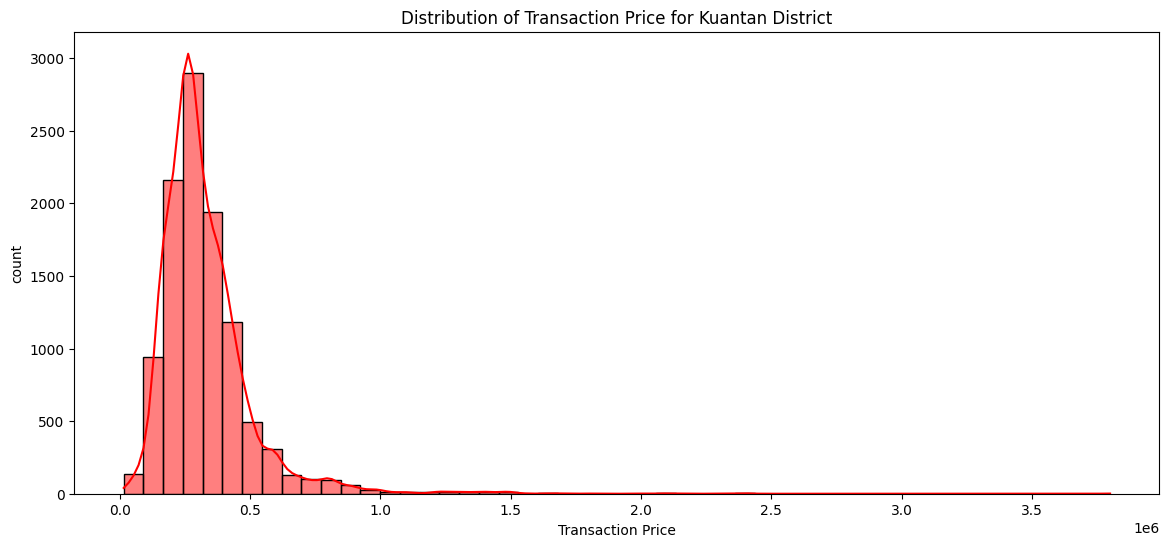


Skewness of Transaction Price: 3.59
Kurtosis of Transaction Price: 30.83





In [26]:

# Distribution of transaction price for Kuantan district
df_kuantan = df_pahang[df_pahang['District'] == 'Kuantan']
plt.figure(figsize=(14, 6))
sns.histplot(df_kuantan['Transaction Price'], bins=50, kde=True, color='red')
plt.title('Distribution of Transaction Price for Kuantan District')
plt.xlabel('Transaction Price')
plt.ylabel('count')
plt.show()

print(f"\nSkewness of Transaction Price: {df_kuantan['Transaction Price'].skew():.2f}")
print(f"Kurtosis of Transaction Price: {df_kuantan['Transaction Price'].kurt():.2f}")

print('\n\n')